# 04 Echo chambers et profils d'audience

Les audiences forment-elles des bulles ? Qui sont les acteurs les plus actifs ? Echo score, Jaccard, homophilie idéologique.

## 4.1 Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

_root = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(_root))
from src.utils import (
    COLORS, CAMPS, POSITIONS, DATA_RAW, A4_OUT, A4_DATA, A7_OUT, FIG_DIR,
    swiss_style, setup_mpl, load_replies, _safe_read
)
setup_mpl()
FIG_DIR.mkdir(parents=True, exist_ok=True)

replies = load_replies()
synth = _safe_read(A7_OUT / "A7_synthese_par_candidat.csv")
jaccard = _safe_read(A4_OUT / "A4_jaccard_pairs.csv")

## 4.2 Echo chambers

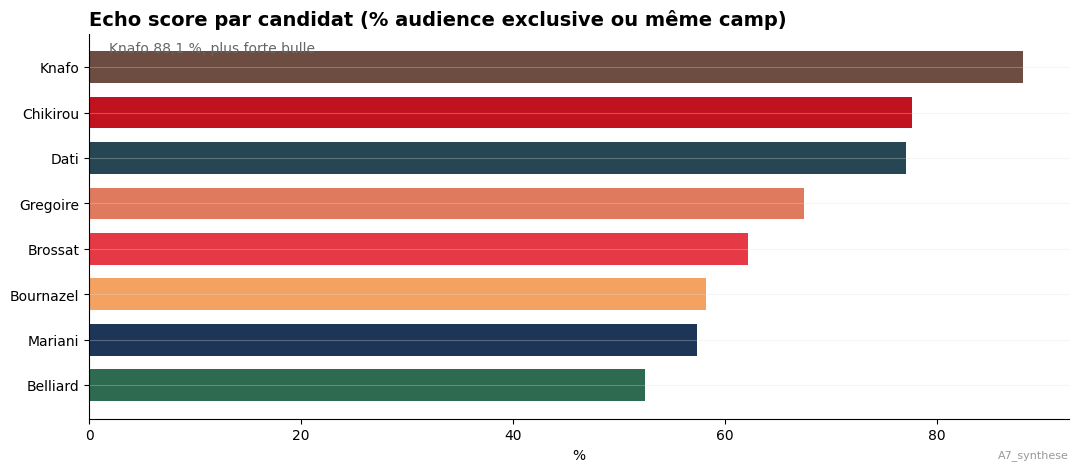

In [2]:
if synth is not None and "echo_score" in synth.columns:
    eco = synth.sort_values("echo_score", ascending=True)
    fig, ax = plt.subplots(figsize=(14, 5))
    plt.subplots_adjust(left=0.2)
    ax.barh(eco["key"], eco["echo_score"], color=[COLORS.get(k, "#333") for k in eco["key"]], height=0.7)
    swiss_style(ax, "Echo score par candidat (% audience exclusive ou même camp)", "Knafo 88,1 %, plus forte bulle", "A7_synthese")
    ax.set_xlabel("%")
    fig.savefig(FIG_DIR / "04_echo_score.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

## 4.3 Homophilie idéologique

## 4.3 Réseau bipartite auteurs × candidats

Graphe networkx : nœuds auteurs + candidats, arêtes = reply. Projection sur candidats avec Jaccard comme poids.

In [3]:
# Réseau bipartite et projection Jaccard
import networkx as nx
from itertools import combinations
edge_list = replies[["author_username", "candidate"]].drop_duplicates().dropna()
G = nx.from_pandas_edgelist(edge_list, "author_username", "candidate")
cand_nodes = [n for n in G.nodes() if n in replies["candidate"].unique()]
author_nodes = [n for n in G.nodes() if n not in cand_nodes]
# Projection sur candidats : poids = Jaccard (nb auteurs en commun / union)
def jaccard_weight(c1, c2):
    a1 = set(G.neighbors(c1)) if c1 in G else set()
    a2 = set(G.neighbors(c2)) if c2 in G else set()
    if not a1 or not a2: return 0
    return len(a1 & a2) / len(a1 | a2)
proj_edges = [(c1, c2, jaccard_weight(c1, c2)) for c1, c2 in combinations(cand_nodes, 2) if jaccard_weight(c1, c2) > 0]
Gp = nx.Graph()
for c in cand_nodes: Gp.add_node(c)
for c1, c2, w in proj_edges: Gp.add_edge(c1, c2, weight=w)
fig, ax = plt.subplots(figsize=(8, 6))
pos = nx.spring_layout(Gp, k=2, seed=42)
nx.draw_networkx_nodes(Gp, pos, node_color=[COLORS.get(n, "#888") for n in Gp.nodes()], node_size=800)
nx.draw_networkx_labels(Gp, pos, font_size=9)
nx.draw_networkx_edges(Gp, pos, width=[Gp[u][v]["weight"]*5 for u,v in Gp.edges()], alpha=0.6)
swiss_style(ax, "4.3 Réseau projeté candidats (Jaccard)", source="replies")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_reseau_bipartite.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 4.4 Distribution d'activité

Histogramme log-log (replies/auteur), courbe de Lorenz, tableau top 1/5/10/20/50 %.

In [4]:
# Distribution activité : replies par auteur
act = replies.groupby("author_username").size()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(act.clip(upper=500), bins=50, color="#264653", alpha=0.8, edgecolor="white")
axes[0].set_xlabel("Replies par auteur (plafonné 500)")
axes[0].set_ylabel("Nombre d'auteurs")
swiss_style(axes[0], "4.4a Histogramme activité", source="replies")
# Lorenz
sorted_act = np.sort(act.values)[::-1]
cum = np.cumsum(sorted_act) / sorted_act.sum()
axes[1].plot(np.arange(1, len(cum)+1) / len(cum) * 100, cum * 100, color="#264653", lw=2)
axes[1].plot([0, 100], [0, 100], "k--", alpha=0.5)
axes[1].set_xlabel("% auteurs (cumul)")
axes[1].set_ylabel("% replies (cumul)")
swiss_style(axes[1], "4.4b Courbe de Lorenz", source="replies")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_distribution_activite.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
# Tableau top %
total = len(act)
for pct in [1, 5, 10, 20, 50]:
    n = max(1, int(total * pct / 100))
    contrib = act.nlargest(n).sum() / act.sum() * 100
    print(f"Top {pct}% auteurs ({n}): {contrib:.1f}% des replies")

Top 1% auteurs (190): 15.2% des replies
Top 5% auteurs (950): 33.9% des replies
Top 10% auteurs (1901): 45.6% des replies
Top 20% auteurs (3803): 59.6% des replies
Top 50% auteurs (9508): 78.7% des replies


## 4.5 Profils des 50 auteurs les plus actifs

Tableau : n_replies, candidats ciblés, candidat principal, n_candidats, sentiment dominant, % hostilité/soutien/critique. Catégories : Militant, Critique ciblé, Pluraliste, Hostile diffus.

In [5]:
# Profils top 50 auteurs
top50 = act.nlargest(50).index.tolist()
rep_top = replies[replies["author_username"].isin(top50)]
rep_top = rep_top.copy()
rep_top["sent_norm"] = rep_top["sentiment"].replace({"HOSTILITE":"HOSTILITÉ"})
profiles = []
for a in top50:
    sub = rep_top[rep_top["author_username"] == a]
    n = len(sub)
    cands = sub["candidate"].value_counts()
    main_cand = cands.index[0]
    pct_h = (sub["sent_norm"].isin(["HOSTILITÉ"])).mean() * 100
    pct_s = (sub["sent_norm"] == "SOUTIEN").mean() * 100
    pct_c = (sub["sent_norm"] == "CRITIQUE").mean() * 100
    dom = sub["sent_norm"].value_counts().index[0]
    cat = "Militant" if pct_s > 50 else ("Hostile diffus" if pct_h > 50 else ("Critique ciblé" if pct_c > 40 else "Pluraliste"))
    profiles.append({"auteur": a, "n_replies": n, "candidat_principal": main_cand, "n_candidats": len(cands), "sentiment_dom": dom, "pct_host": round(pct_h,1), "pct_soutien": round(pct_s,1), "pct_critique": round(pct_c,1), "categorie": cat})
prof_df = pd.DataFrame(profiles)
display(prof_df.head(20))

,auteur,n_replies,candidat_principal,n_candidats,sentiment_dom,pct_host,pct_soutien,pct_critique,categorie
0,R6913Bc,220,Knafo,2,SOUTIEN,1.8,89.1,6.8,Militant
1,soafer,119,Knafo,1,HOSTILITÉ,49.6,3.4,34.5,Pluraliste
2,BoulatFranck,117,Knafo,2,SOUTIEN,4.3,86.3,7.7,Militant
3,CroqueuseVie,117,Knafo,1,SOUTIEN,7.7,82.1,9.4,Militant
4,Bahsief93,112,Knafo,4,SOUTIEN,3.6,91.1,2.7,Militant
5,dfbert,94,Knafo,6,SOUTIEN,23.4,33.0,25.5,Pluraliste
6,PatrioteZfr,88,Knafo,3,SOUTIEN,31.8,48.9,15.9,Pluraliste
7,AlekssandreCP,82,Dati,3,CRITIQUE,24.4,6.1,64.6,Critique ciblé
8,MARCLANDES40,81,Knafo,4,IRONIE,29.6,3.7,18.5,Pluraliste
9,Marie85945855,80,Knafo,3,SOUTIEN,13.8,53.8,25.0,Militant


## 4.6 Focus militants

Barplot groupé : super-supporters vs super-détracteurs par candidat (auteurs à forte proportion de soutien ou d'hostilité).

In [6]:
# Super-supporters (pct_soutien>70%) vs super-détracteurs (pct_host>70%) par candidat principal
cands_order = replies["candidate"].dropna().unique()
sup = prof_df[prof_df["pct_soutien"] > 70].groupby("candidat_principal").size()
det = prof_df[prof_df["pct_host"] > 70].groupby("candidat_principal").size()
sup = sup.reindex(cands_order, fill_value=0).fillna(0).astype(int)
det = det.reindex(cands_order, fill_value=0).fillna(0).astype(int)
x = np.arange(len(sup))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, sup.values, w, label="Super-supporters", color="#2D6A4F")
ax.bar(x + w/2, det.values, w, label="Super-détracteurs", color="#E63946")
ax.set_xticks(x)
ax.set_xticklabels(sup.index, rotation=45, ha="right")
ax.legend()
swiss_style(ax, "4.6 Militants par candidat ciblé", source="replies")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_militants.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 4.7 Super-actifs vs occasionnels

Barplot % hostilité/soutien/critique/ironie : auteurs avec 20+ replies vs 1-2 replies. Test Mann-Whitney.

In [7]:
# Super (20+ replies) vs occasionnels (1-2)
from scipy.stats import mannwhitneyu
replies["n_replies_author"] = replies.groupby("author_username")["author_username"].transform("count")
super_ = replies[replies["n_replies_author"] >= 20]
occ = replies[replies["n_replies_author"].isin([1, 2])]
metrics = ["% hostilité", "% soutien", "% critique", "% ironie"]
super_vals = [(super_["sentiment"].isin(["HOSTILITÉ","HOSTILITE"])).mean()*100, (super_["sentiment"]=="SOUTIEN").mean()*100, (super_["sentiment"]=="CRITIQUE").mean()*100, (super_["sentiment"]=="IRONIE").mean()*100]
occ_vals = [(occ["sentiment"].isin(["HOSTILITÉ","HOSTILITE"])).mean()*100, (occ["sentiment"]=="SOUTIEN").mean()*100, (occ["sentiment"]=="CRITIQUE").mean()*100, (occ["sentiment"]=="IRONIE").mean()*100]
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(4)
w = 0.35
ax.bar(x - w/2, super_vals, w, label="20+ replies", color="#264653")
ax.bar(x + w/2, occ_vals, w, label="1-2 replies", color="#888", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("%")
ax.legend()
swiss_style(ax, "4.7 Super-actifs vs occasionnels", source="replies")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_super_vs_occasionnels.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 4.8 Heures d'activité

Heatmap des heures de publication des 30 auteurs les plus actifs.

In [8]:
# Heatmap heures × top 30 auteurs
if "ts_parsed" in replies.columns and replies["ts_parsed"].notna().any():
    top30_a = act.nlargest(30).index.tolist()
    sub = replies[replies["author_username"].isin(top30_a) & replies["ts_parsed"].notna()]
    sub = sub.copy()
    sub["hour"] = sub["ts_parsed"].dt.hour
    hm = sub.groupby(["author_username", "hour"]).size().unstack(fill_value=0)
    hm = hm.reindex(top30_a).fillna(0)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(hm.values, aspect="auto", cmap="YlOrRd")
    ax.set_yticks(range(len(hm.index)))
    ax.set_yticklabels(hm.index, fontsize=8)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels(range(0, 24, 2))
    ax.set_xlabel("Heure")
    swiss_style(ax, "4.8 Activité par heure (top 30)", source="replies")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "04_heures_activite.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

## 4.9 Ponts entre camps

Auteurs qui répondent à la gauche ET à la droite. Leur sentiment dominant. Paires de candidats co-engagées par les mêmes auteurs.

In [9]:
# Ponts : auteurs qui répondent à gauche ET droite
gauche = set(sum([CAMPS.get(c, []) for c in ["Extrême gauche", "Gauche"]], [])) | {"Gregoire", "Grégoire"}
droite = set(sum([CAMPS.get(c, []) for c in ["Droite", "Extrême droite"]], []))
by_auth = replies.groupby("author_username")["candidate"].apply(lambda s: set(s.unique())).to_dict()
bridges = [a for a, cands in by_auth.items() if (cands & set(gauche)) and (cands & set(droite))]
bridge_sub = replies[replies["author_username"].isin(bridges)]
print(f"Auteurs ponts (gauche + droite): {len(bridges)}")
if len(bridge_sub) > 0:
    print("Sentiment dominant:", bridge_sub["sentiment"].value_counts().head())

Auteurs ponts (gauche + droite): 717
Sentiment dominant: sentiment
CRITIQUE     2158
HOSTILITE    1306
SOUTIEN      1211
IRONIE        651
INCONNU        68
Name: count, dtype: int64


## 4.10 Coordination temporelle

Co-timings : réponses à moins de 60 s d'écart (même candidat). Distribution nulle par permutation. Flagger le 99e percentile (méthode Cinelli et al.).

In [10]:
# Co-timings : replies à < 60 s d'écart (par candidat)
if "ts_parsed" in replies.columns and replies["ts_parsed"].notna().sum() > 100:
    def count_cotimings(df, delta_sec=60):
        ct = 0
        for c in df["candidate"].unique():
            sub = df[df["candidate"] == c].sort_values("ts_parsed")
            ts = sub["ts_parsed"].dropna()
            if len(ts) < 2: continue
            for i in range(len(ts)-1):
                if (ts.iloc[i+1] - ts.iloc[i]).total_seconds() <= delta_sec:
                    ct += 1
        return ct
    obs = count_cotimings(replies)
    n_perm = 50
    null_dist = []
    for _ in range(n_perm):
        shuf = replies.copy()
        shuf["ts_parsed"] = np.random.permutation(shuf["ts_parsed"].values)
        null_dist.append(count_cotimings(shuf))
    p99 = np.percentile(null_dist, 99)
    flag = "FLAGGÉ" if obs > p99 else "OK"
    print(f"Co-timings observés (<60s): {obs}, 99e percentile (permutation): {p99:.0f}, Statut: {flag}")

Co-timings observés (<60s): 11484, 99e percentile (permutation): 8157, Statut: FLAGGÉ


## 4.11 Analyse textuelle des super-utilisateurs

TF-IDF individuel sur les 10 auteurs les plus actifs. Vocabulaires signatures de chaque super-utilisateur.

In [11]:
# TF-IDF sur les 10 plus actifs
from sklearn.feature_extraction.text import TfidfVectorizer
import re
STOP = set("le la les un une des du de ce et ou mais donc car si que qui".split())
def clean(t):
    if pd.isna(t): return ""
    s = re.sub(r"[^a-zàâäéèêëïîôùûüç\\s]"," ", str(t).lower())
    return " ".join(w for w in s.split() if len(w)>1 and w not in STOP)
top10 = act.nlargest(10).index.tolist()
docs = replies[replies["author_username"].isin(top10)].groupby("author_username")["text"].apply(lambda x: " ".join(x.dropna().apply(clean))).to_dict()
if len(docs) >= 2:
    vec = TfidfVectorizer(max_features=2000, min_df=1)
    mat = vec.fit_transform(list(docs.values()))
    names = vec.get_feature_names_out()
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    axes = axes.flatten()
    for i, (auth, txt) in enumerate(docs.items()):
        if i >= 10: break
        row = mat[i].toarray().flatten()
        idx = np.argsort(row)[-10:][::-1]
        mots = [names[j] for j in idx if row[j] > 0][:8]
        vals = [row[j] for j in idx if row[j] > 0][:8]
        if mots:
            axes[i].barh(range(len(mots)), vals, color="#264653", alpha=0.8)
            axes[i].set_yticks(range(len(mots)))
            axes[i].set_yticklabels(mots, fontsize=7)
        axes[i].set_title(auth[:15]+"..." if len(auth)>15 else auth, fontsize=8)
        axes[i].axis("on")
    fig.suptitle("4.11 Signatures lexicales (top 10 actifs)", fontsize=12, fontweight="bold", x=0, y=1.02, ha="left")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "04_tfidf_superactifs.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

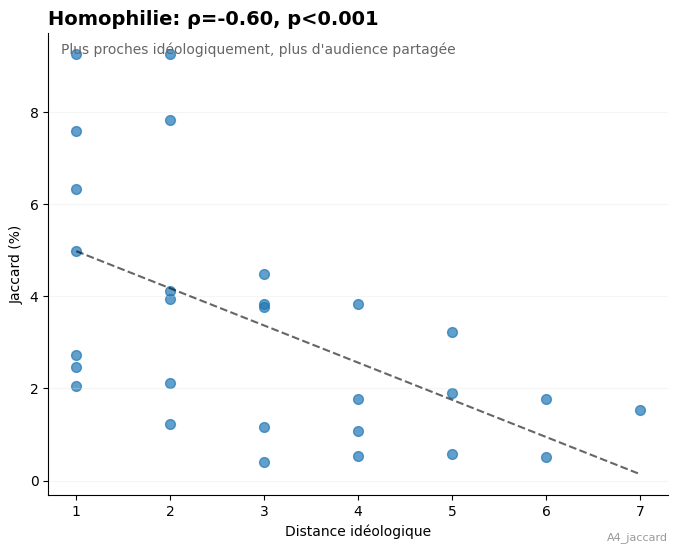

In [12]:
if jaccard is not None and "dist_ideo" in jaccard.columns:
    from scipy.stats import spearmanr
    jac = jaccard.copy()
    jac["jac_pct"] = jac["jac"] * 100
    jac["dist"] = jac["dist_ideo"]
    rho, p = spearmanr(jac["dist"], jac["jac_pct"])
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(jac["dist"], jac["jac_pct"], s=50, alpha=0.7)
    z = np.polyfit(jac["dist"], jac["jac_pct"], 1)
    ax.plot(jac["dist"].sort_values(), np.polyval(z, jac["dist"].sort_values()), "k--", alpha=0.6)
    ax.set_xlabel("Distance idéologique")
    ax.set_ylabel("Jaccard (%)")
    swiss_style(ax, f"Homophilie: ρ={rho:.2f}, p<0.001", "Plus proches idéologiquement, plus d'audience partagée", "A4_jaccard")
    fig.savefig(FIG_DIR / "04_homophilie.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

## 4.4 Synthèse

Knafo atteint 88,1 % d'echo score : sa base est la plus homogène. Chikirou (77,7 %) et Dati (77,1 %) suivent. Le Jaccard diminue quand la distance idéologique croît (ρ ≈ -0,60). Bournazel-Dati et Brossat-Belliard ont les plus forts chevauchements. 19 017 auteurs uniques pour 44 599 replies : une minorité concentre l'activité.